# Model selection

Model selection by 5-fold cross validation.

In [ ]:
import torch
from torch.distributions import Normal
import gpytorch
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy
from gpytorch.means import Mean, ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

try:
    import sys
    import os

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


N = 100
x = torch.linspace(0, 1, N).reshape(-1, 1).to(device)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.linspace(0.1, 0.9, 9).to(device)
true_quantiles = mean(x) + std(x) * Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

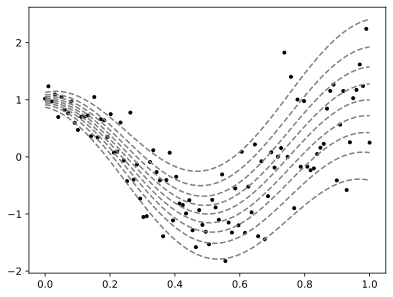

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

In [ ]:
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

x_train_list, y_train_list, x_test_list, y_test_list = [], [], [], []
for train_idx, test_idx in kf.split(x.cpu()):
    x_train_list.append(x[train_idx])
    y_train_list.append(y[train_idx])
    x_test_list.append(x[test_idx])
    y_test_list.append(y[test_idx])

x_train_cv = torch.stack(x_train_list).to(device)
y_train_cv = torch.stack(y_train_list).to(device)
x_test_cv = torch.stack(x_test_list).to(device)
y_test_cv = torch.stack(y_test_list).to(device)

## Batch direct GPQR

In [ ]:
from gpytorch_qr.gpqr import BatchQuantileGP, BatchALDLikelihood


class CVBatchQuantileGP(BatchQuantileGP):
    def __init__(self, inducing_points, num_quantiles, num_folds):
        N, D = inducing_points.size()
        batch_shape = torch.Size([num_quantiles, num_folds])
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=batch_shape,
        )
        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )
        mean = ConstantMean(batch_shape=batch_shape)
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=batch_shape),
            batch_shape=batch_shape,
        )
        super().__init__(variational_strategy, mean, covar)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
gpqr = CVBatchQuantileGP(inducing_points, len(q), K).to(device)
likelihood_gpqr = BatchALDLikelihood(q.unsqueeze(1), torch.zeros((len(q), K))).to(
    device
)

In [ ]:
mll = VariationalELBO(likelihood_gpqr, gpqr, num_data=y_train_cv.shape[1])
optimizer = torch.optim.Adam(
    list(gpqr.parameters()) + list(likelihood_gpqr.parameters()),
    lr=0.001,
)

gpqr_train_losses, gpqr_test_losses = [], []
for _ in range(5000):
    gpqr.train()
    likelihood_gpqr.train()

    output = gpqr(x_train_cv)
    train_loss = -mll(output, y_train_cv).sum()
    train_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    gpqr.eval()
    likelihood_gpqr.eval()
    with torch.no_grad():
        output = gpqr(x_test_cv)
        test_loss = -mll(output, y_test_cv).sum()

    gpqr_train_losses.append(train_loss.item() / K)
    gpqr_test_losses.append(test_loss.item() / K)

## Batch center-gap GPQR

In [ ]:
from gpytorch_qr.gpqr_cg import (
    BatchCenterGapQuantileGP,
    BatchCenterGapALDLikelihood,
)


class CVBatchCenterGapQuantileGP(BatchCenterGapQuantileGP):
    def __init__(self, inducing_points, num_quantiles, num_folds, num_lower_quantiles):
        N, D = inducing_points.size()
        batch_shape = torch.Size([num_quantiles, num_folds])
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=batch_shape,
        )
        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        center_mean = ConstantMean(batch_shape=torch.Size([num_folds]))
        gap_mean = ConstantMean(batch_shape=torch.Size([num_quantiles - 1, num_folds]))
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=batch_shape),
            batch_shape=batch_shape,
        )
        super().__init__(
            variational_strategy, center_mean, gap_mean, covar, num_lower_quantiles
        )


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
central_q_index = (q - 0.5).abs().argmin().item()
num_lower_quantiles = central_q_index
gpqr_cg = CVBatchCenterGapQuantileGP(
    inducing_points, len(q), K, num_lower_quantiles
).to(device)
likelihood_gpqr_cg = BatchCenterGapALDLikelihood(
    q.unsqueeze(1), central_q_index, torch.zeros((len(q), K))
).to(device)

In [ ]:
mll = VariationalELBO(likelihood_gpqr_cg, gpqr_cg, num_data=y_train_cv.shape[1])
optimizer = torch.optim.Adam(
    list(gpqr_cg.parameters()) + list(likelihood_gpqr_cg.parameters()),
    lr=0.001,
)

gpqr_cg_train_losses, gpqr_cg_test_losses = [], []
for _ in range(5000):
    gpqr_cg.train()
    likelihood_gpqr_cg.train()

    output = gpqr_cg(x_train_cv)
    train_loss = -mll(output, y_train_cv).sum()
    train_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    gpqr_cg.eval()
    likelihood_gpqr_cg.eval()
    with torch.no_grad():
        output = gpqr_cg(x_test_cv)
        test_loss = -mll(output, y_test_cv).sum()

    gpqr_cg_train_losses.append(train_loss.item() / K)
    gpqr_cg_test_losses.append(test_loss.item() / K)

## Plot loss by epoch

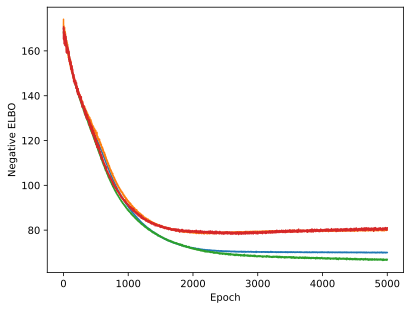

In [ ]:
plt.plot(gpqr_train_losses)
plt.plot(gpqr_test_losses)
plt.plot(gpqr_cg_train_losses)
plt.plot(gpqr_cg_test_losses)
plt.xlabel("Epoch")
plt.ylabel("Negative ELBO")
plt.show()